<a href="https://colab.research.google.com/github/frankZawacki/DSP566GroupProj_Colab/blob/dev/Zawacki_DSP566_Assign6_Text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Helper to show Markdown explanations nicely in notebooks
try:
    from IPython.display import display, Markdown
    def explain(md): display(Markdown(md))
except Exception:
    def explain(md): print("\n" + md + "\n")


In [2]:
explain("""
# Part 1 — Text Classification with RNNs (AG News)
We will load **ag_news_subset** from TensorFlow Datasets, tokenize & pad text using
`TextVectorization`, build an RNN classifier (Embedding → LSTM/GRU → Dense softmax),
train/evaluate, plot training curves, and run a small hyperparameter sweep.

**Note:** Despite the prompt referencing "20 classes", `ag_news_subset` has **4 classes**.
We'll confirm programmatically from the dataset info.
""")


# Part 1 — Text Classification with RNNs (AG News)
We will load **ag_news_subset** from TensorFlow Datasets, tokenize & pad text using
`TextVectorization`, build an RNN classifier (Embedding → LSTM/GRU → Dense softmax),
train/evaluate, plot training curves, and run a small hyperparameter sweep.

**Note:** Despite the prompt referencing "20 classes", `ag_news_subset` has **4 classes**.
We'll confirm programmatically from the dataset info.


In [3]:
# ============================================================
# Text Classification with RNNs (AG News) + Convolutional Autoencoder (MNIST)
#
# ============================================================

import os, warnings, itertools, math, random
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models, callbacks, regularizers

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)


# ============================================================
# PART 1: TEXT CLASSIFICATION WITH RNNs (AG News Subset)
# ============================================================


# ------------------------
# Load & Inspect the data
# ------------------------
ag_splits, ag_info = tfds.load('ag_news_subset', as_supervised=True, with_info=True, split=['train', 'test'])
train_raw_full, test_raw = ag_splits
label_names = ag_info.features['label'].names
num_classes = ag_info.features['label'].num_classes

explain(f"""
**Dataset summary**
- Number of classes: **{num_classes}**
- Label names: **{label_names}**
- Splits: train={ag_info.splits['train'].num_examples}, test={ag_info.splits['test'].num_examples}

Create a validation split from the training data.
""")

# Create validation split from train (e.g., 10%)
train_count = ag_info.splits['train'].num_examples
val_size = int(0.1 * train_count)

train_raw = train_raw_full.skip(val_size)
val_raw   = train_raw_full.take(val_size)

# ------------------------
# Vectorization (tokenization + padding)
# ------------------------
VOCAB_SIZE         = 30000
SEQUENCE_LENGTH    = 200   # padding/truncation length
EMBED_DIM          = 128

# Build TextVectorization
vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=SEQUENCE_LENGTH,
    standardize='lower_and_strip_punctuation',
)

# Adapt on training text only
text_only_ds = train_raw.map(lambda txt, y: txt)
vectorizer.adapt(text_only_ds)

# Vectorize datasets and batch/prefetch
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 128

def vectorize_fn(text, label):
    return vectorizer(text), label

def make_ds(ds, training=False):
    ds = ds.map(vectorize_fn, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(10_000, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_raw, training=True)
val_ds   = make_ds(val_raw, training=False)
test_ds  = make_ds(test_raw, training=False)








TensorFlow: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

...

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.HBRPOI_1.0.0/ag_news_subset-train.tfrecord*...: …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.HBRPOI_1.0.0/ag_news_subset-test.tfrecord*...:  …

Dataset ag_news_subset downloaded and prepared to /root/tensorflow_datasets/ag_news_subset/1.0.0. Subsequent calls will reuse this data.



**Dataset summary**
- Number of classes: **4**
- Label names: **['World', 'Sports', 'Business', 'Sci/Tech']**
- Splits: train=120000, test=7600

Create a validation split from the training data.


In [4]:
explain("""
### Tokenization & Padding
We used `TextVectorization` to:
- build a vocabulary (max 30k tokens),
- map text to integer IDs,
- pad/truncate each example to a fixed length (**200**).

This ensures RNNs receive uniform-length sequences.
""")


### Tokenization & Padding
We used `TextVectorization` to:
- build a vocabulary (max 30k tokens),
- map text to integer IDs,
- pad/truncate each example to a fixed length (**200**).

This ensures RNNs receive uniform-length sequences.


In [5]:
# ------------------------
# Model builder
# ------------------------
def build_rnn_model(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    rnn_type='LSTM',   # 'LSTM' or 'GRU'
    rnn_units=128,
    rnn_layers=1,      # 1 or 2
    dropout=0.3,
    lr=1e-3,
    num_classes=num_classes
):
    inputs = layers.Input(shape=(SEQUENCE_LENGTH,), dtype='int32')
    x = layers.Embedding(vocab_size, embed_dim, mask_zero=True)(inputs)

    RNN = layers.LSTM if rnn_type.upper() == 'LSTM' else layers.GRU

    if rnn_layers == 1:
        x = RNN(rnn_units, return_sequences=False, dropout=dropout, recurrent_dropout=0.0)(x)
    else:
        # First RNN returns sequences for stacking
        x = RNN(rnn_units, return_sequences=True, dropout=dropout, recurrent_dropout=0.0)(x)
        x = RNN(rnn_units, return_sequences=False, dropout=dropout, recurrent_dropout=0.0)(x)

    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs, name=f'{rnn_type}_{rnn_layers}x{rnn_units}')

    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model



## Train a Baseline RNN
We'll start with a single-layer **LSTM(128)**, dropout=0.3, lr=1e-3.
**Interpretation**: Watch training/validation curves. If train improves but val stalls or diverges, it's overfitting; increase dropout or reduce capacity.


Model: "LSTM_1x128"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  3,840,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 200)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │    131,584 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        516 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,972,100 (15.15 MB)

 Trainable params: 3,972,100 (15.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7751 - loss: 0.5773
Epoch 1: val_accuracy improved from -inf to 0.90700, saving model to ckpt_agnews/best_baseline.h5


844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7753 - loss: 0.5769 - val_accuracy: 0.9070 - val_loss: 0.2862
Epoch 2/6
838/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9234 - loss: 0.2337
Epoch 2: val_accuracy did not improve from 0.90700
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9234 - loss: 0.2337 - val_accuracy: 0.9014 - val_loss: 0.2967
Epoch 3/6
842/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9396 - loss: 0.1837
Epoch 3: val_accuracy did not improve from 0.90700
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9396 - loss: 0.1837 - val_accuracy: 0.9051 - val_loss: 0.2901
Epoch 4/6
841/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9503 - loss: 0.1464
Epoch 4: val_accuracy did not improve from 0.90700
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9503 - loss: 0.1464 - val_accuracy: 0.8981 - val_loss: 0.3386
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


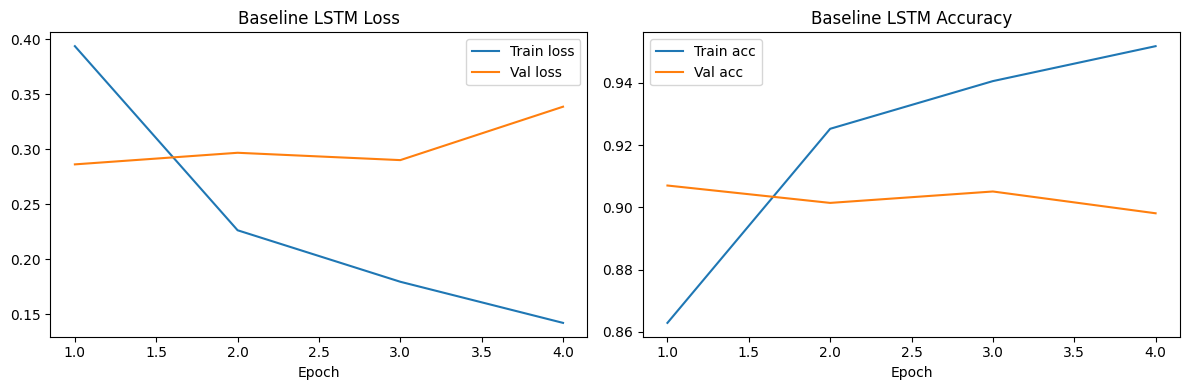

60/60 - 0s - 7ms/step - accuracy: 0.9042 - loss: 0.2876


**Baseline Test Performance:** accuracy=0.9042, loss=0.2876

In [6]:
# ------------------------
# Train a baseline model
# ------------------------
explain("""
## Train a Baseline RNN
We'll start with a single-layer **LSTM(128)**, dropout=0.3, lr=1e-3.
**Interpretation**: Watch training/validation curves. If train improves but val stalls or diverges, it's overfitting; increase dropout or reduce capacity.
""")

baseline = build_rnn_model(rnn_type='LSTM', rnn_units=128, rnn_layers=1, dropout=0.3, lr=1e-3)
baseline.summary()

ckpt_dir = "ckpt_agnews"
os.makedirs(ckpt_dir, exist_ok=True)
ckpt_path = os.path.join(ckpt_dir, "best_baseline.h5")
cbs = [
    callbacks.ModelCheckpoint(ckpt_path, save_best_only=True, monitor='val_accuracy', mode='max', verbose=1),
    callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy', mode='max', verbose=1)
]

history = baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=cbs,
    verbose=1
)

# Plot training curves
def plot_history(h, title_prefix=''):
    loss = h.history['loss']; val_loss = h.history['val_loss']
    acc = h.history['accuracy']; val_acc = h.history['val_accuracy']
    epochs = np.arange(1, len(loss)+1)

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='Train loss')
    plt.plot(epochs, val_loss, label='Val loss')
    plt.title(f'{title_prefix} Loss'); plt.xlabel('Epoch'); plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='Train acc')
    plt.plot(epochs, val_acc, label='Val acc')
    plt.title(f'{title_prefix} Accuracy'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_history(history, "Baseline LSTM")

# Evaluate on test
test_loss, test_acc = baseline.evaluate(test_ds, verbose=2)
explain(f"**Baseline Test Performance:** accuracy={test_acc:.4f}, loss={test_loss:.4f}")


In [7]:
# ------------------------
# Light hyperparameter sweep
# ------------------------
explain("""
## Hyperparameter Tuning (light)
We'll try a few variants: GRU vs LSTM, units (64/128), dropout (0.2/0.4), LR (1e-3/5e-4).
**Goal:** See which combination yields best validation accuracy (no cross-val needed).
""")

search_space = [
    ('LSTM', 128, 0.3, 1e-3),
    ('GRU',  128, 0.3, 1e-3),
    ('LSTM', 64,  0.4, 5e-4),
]

results = []
for rnn_type, units, drop, lr in search_space:
    model = build_rnn_model(rnn_type=rnn_type, rnn_units=units, rnn_layers=1, dropout=drop, lr=lr)
    h = model.fit(train_ds, validation_data=val_ds, epochs=4, verbose=0)
    val_acc = h.history['val_accuracy'][-1]
    test_res = model.evaluate(test_ds, verbose=0)
    results.append({
        'model': model.name,
        'rnn_type': rnn_type,
        'units': units,
        'dropout': drop,
        'lr': lr,
        'val_acc': float(val_acc),
        'test_acc': float(test_res[1]),
        'test_loss': float(test_res[0]),
    })
    print(f"Trial {model.name} -> val_acc={val_acc:.4f} test_acc={test_res[1]:.4f}")

# Show tuning summary
import pandas as pd
df_results = pd.DataFrame(results).sort_values('val_acc', ascending=False)
explain("### Tuning Summary (sorted by validation accuracy)")
print(df_results)




## Hyperparameter Tuning (light)
We'll try a few variants: GRU vs LSTM, units (64/128), dropout (0.2/0.4), LR (1e-3/5e-4).
**Goal:** See which combination yields best validation accuracy (no cross-val needed).


Trial LSTM_1x128 -> val_acc=0.9002 test_acc=0.8997
Trial GRU_1x128 -> val_acc=0.9025 test_acc=0.8978
Trial LSTM_1x64 -> val_acc=0.9034 test_acc=0.9008


### Tuning Summary (sorted by validation accuracy)

        model rnn_type  units  dropout      lr   val_acc  test_acc  test_loss
2   LSTM_1x64     LSTM     64      0.4  0.0005  0.903417  0.900789   0.306557
1   GRU_1x128      GRU    128      0.3  0.0010  0.902500  0.897763   0.333984
0  LSTM_1x128     LSTM    128      0.3  0.0010  0.900167  0.899737   0.316372


In [8]:
explain("""
# Part 2 — Convolutional Autoencoder (MNIST) + PCA Comparison

**Goal:** Learn a compressed representation and reconstruct digits.
- We'll hold **all '3' digits** and **a fraction of every other digit** out as test.
- Build a small **conv autoencoder** (encoder: Conv/Pool; decoder: ConvTranspose/UpSampling).
- Use a reconstruction loss (**binary crossentropy** with sigmoid output is common).
- Evaluate reconstruction error overall and specifically on digit '3'.
- Visualize original vs reconstructed images.

We'll also fit a quick **linear PCA** baseline to show the contrast.
""")


# Part 2 — Convolutional Autoencoder (MNIST) + PCA Comparison

**Goal:** Learn a compressed representation and reconstruct digits.
- We'll hold **all '3' digits** and **a fraction of every other digit** out as test.
- Build a small **conv autoencoder** (encoder: Conv/Pool; decoder: ConvTranspose/UpSampling).
- Use a reconstruction loss (**binary crossentropy** with sigmoid output is common).
- Evaluate reconstruction error overall and specifically on digit '3'.
- Visualize original vs reconstructed images.

We'll also fit a quick **linear PCA** baseline to show the contrast.


In [9]:
# ============================================================
# PART 2: CONVOLUTIONAL AUTOENCODER (MNIST) + PCA COMPARISON
# ============================================================



# ------------------------
# Load and split MNIST
# ------------------------
(X_train_full, y_train_full), (X_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()
# Combine for our custom split
X_all = np.concatenate([X_train_full, X_test_full], axis=0)
y_all = np.concatenate([y_train_full, y_test_full], axis=0)

# Normalize to [0,1] and add channel dimension
X_all = X_all.astype("float32") / 255.0
X_all = np.expand_dims(X_all, axis=-1)  # (N, 28, 28, 1)

# Build custom train/test: all '3's + a fraction (e.g., 10%) of non-3s go to test
fraction_non3_test = 0.10

idx_3   = np.where(y_all == 3)[0]
idx_not = np.where(y_all != 3)[0]

# Take all 3s for test
test_idx_3 = idx_3

# Sample 10% of non-3s for test
num_non3_test = int(fraction_non3_test * len(idx_not))
rng = np.random.default_rng(42)
test_idx_non3 = rng.choice(idx_not, size=num_non3_test, replace=False)

test_idx = np.concatenate([test_idx_3, test_idx_non3])
train_mask = np.ones(len(y_all), dtype=bool)
train_mask[test_idx] = False
train_idx = np.where(train_mask)[0]

X_train = X_all[train_idx]
X_test  = X_all[test_idx]
y_train = y_all[train_idx]
y_test  = y_all[test_idx]

explain(f"""
**Custom split**
- Train size: {X_train.shape[0]}
- Test size: {X_test.shape[0]} (includes **all 3s** and ~{int(100*fraction_non3_test)}% of other digits)
- Input shape: {X_train.shape[1:]}
""")




11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step



**Custom split**
- Train size: 56574
- Test size: 13426 (includes **all 3s** and ~10% of other digits)
- Input shape: (28, 28, 1)


In [10]:
explain(f"""
**Custom split**
- Train size: {X_train.shape[0]}
- Test size: {X_test.shape[0]} (includes **all 3s** and ~{int(100*fraction_non3_test)}% of other digits)
- Input shape: {X_train.shape[1:]}
""")


**Custom split**
- Train size: 56574
- Test size: 13426 (includes **all 3s** and ~10% of other digits)
- Input shape: (28, 28, 1)


Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │       200,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6272)           │       206,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,929 (2.26 MB)

 Trainable params: 592,929 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

...

199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0759 - val_loss: 0.0762
Epoch 17/20
196/199 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0756
Epoch 17: val_loss improved from 0.07621 to 0.07549, saving model to ckpt_mnist_auto/best_auto.h5


199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0756 - val_loss: 0.0755
Epoch 18/20
196/199 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0752
Epoch 18: val_loss improved from 0.07549 to 0.07511, saving model to ckpt_mnist_auto/best_auto.h5


199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0752 - val_loss: 0.0751
Epoch 19/20
198/199 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0750
Epoch 19: val_loss improved from 0.07511 to 0.07482, saving model to ckpt_mnist_auto/best_auto.h5


199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0750 - val_loss: 0.0748
Epoch 20/20
198/199 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0745
Epoch 20: val_loss improved from 0.07482 to 0.07451, saving model to ckpt_mnist_auto/best_auto.h5


199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0745 - val_loss: 0.0745
Restoring model weights from the end of the best epoch: 20.


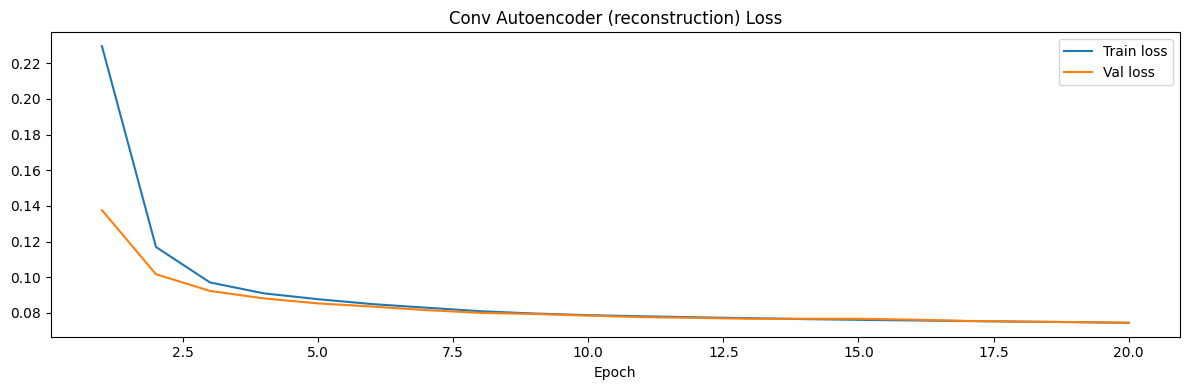

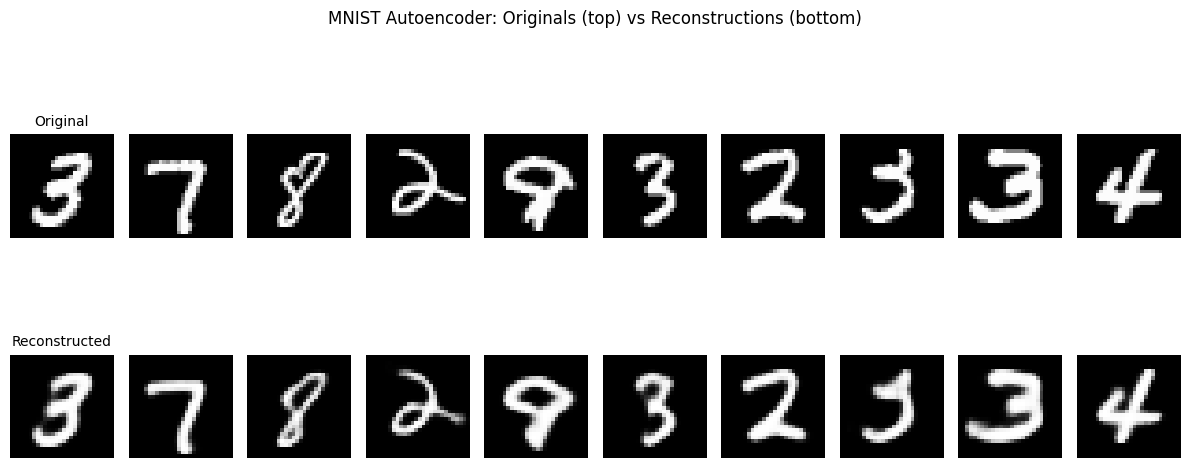


**Autoencoder test reconstruction loss (lower is better)**
- Overall test: **0.0860**
- Digit '3' only: **0.0957**

Interpretation: If the '3' subset has noticeably higher loss than overall, the model has a harder time reconstructing 3s (possibly due to holding **all** 3s out of training).


In [11]:
# ------------------------
# Convolutional Autoencoder
# ------------------------
def build_conv_autoencoder(latent_dim=32):
    # Encoder
    inp = layers.Input(shape=(28,28,1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D()(x)             # 14x14
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)             # 7x7
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, activation='relu', name='latent')(x)

    # Decoder
    x = layers.Dense(7*7*128, activation='relu')(latent)
    x = layers.Reshape((7,7,128))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)  # 14x14
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)  # 28x28
    out = layers.Conv2D(1, 3, padding='same', activation='sigmoid')(x)

    auto = models.Model(inp, out, name='conv_autoencoder')
    # Loss: binary_crossentropy (common with sigmoid output & normalized [0,1] pixels)
    auto.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy')
    return auto

auto = build_conv_autoencoder(latent_dim=32)
auto.summary()

# Train autoencoder
ckpt_dir = "ckpt_mnist_auto"
os.makedirs(ckpt_dir, exist_ok=True)
ckpt_path = os.path.join(ckpt_dir, "best_auto.h5")
cbs_auto = [
    callbacks.ModelCheckpoint(ckpt_path, save_best_only=True, monitor='val_loss', mode='min', verbose=1),
    callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss', mode='min', verbose=1),
]
hist_auto = auto.fit(
    X_train, X_train,   # input == target (unsupervised reconstruction)
    validation_split=0.1,
    epochs=20,
    batch_size=256,
    callbacks=cbs_auto,
    verbose=1
)

# Plot reconstruction loss curves
def plot_history(h, title_prefix=''):
    loss = h.history['loss']; val_loss = h.history['val_loss']
    acc = h.history.get('accuracy'); val_acc = h.history.get('val_accuracy') # Use .get for optional metrics
    epochs = np.arange(1, len(loss)+1)

    plt.figure(figsize=(12,4))
    # Adjust subplot layout based on whether accuracy metric is available
    num_cols = 2 if acc is not None else 1
    if num_cols == 1:
        plt.subplot(111)
    else:
        plt.subplot(1, num_cols, 1)
    plt.plot(epochs, loss, label='Train loss')
    plt.plot(epochs, val_loss, label='Val loss')
    plt.title(f'{title_prefix} Loss'); plt.xlabel('Epoch'); plt.legend()

    if acc is not None:
        plt.subplot(1, num_cols, 2)
        plt.plot(epochs, acc, label='Train acc')
        plt.plot(epochs, val_acc, label='Val acc')
        plt.title(f'{title_prefix} Accuracy'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_history(hist_auto, "Conv Autoencoder (reconstruction)")

# Evaluate reconstruction error (binary crossentropy) on overall test and test 3s
test_loss_all = auto.evaluate(X_test, X_test, verbose=0)
X_test_3 = X_test[y_test == 3]
test_loss_3  = auto.evaluate(X_test_3, X_test_3, verbose=0) if len(X_test_3) > 0 else float('nan')



# Visualize reconstructions (10 samples, ensure at least one '3' if available)
def plot_reconstructions(model, X, y, n=10):
    # Try to include at least one '3' if present
    idxs = np.arange(len(X))
    rng = np.random.default_rng(7)
    chosen = []
    if np.any(y == 3):
        # include one 3
        idx_3 = idxs[y == 3]
        chosen.append(rng.choice(idx_3))
        # fill the rest
        remaining = np.setdiff1d(idxs, chosen)
        chosen.extend(list(rng.choice(remaining, size=n-1, replace=False)))
    else:
        chosen = list(rng.choice(idxs, size=n, replace=False))

    samples = X[chosen]
    preds = model.predict(samples, verbose=0)

    plt.figure(figsize=(12, 3*n//5 if n>5 else 6))
    for i in range(n):
        # original
        ax = plt.subplot(2, n, i+1)
        plt.imshow(samples[i].squeeze(), cmap='gray')
        plt.axis('off')
        if i == 0:
            ax.set_title("Original", fontsize=10)

        # reconstructed
        ax = plt.subplot(2, n, i+1+n)
        plt.imshow(preds[i].squeeze(), cmap='gray')
        plt.axis('off')
        if i == 0:
            ax.set_title("Reconstructed", fontsize=10)
    plt.suptitle("MNIST Autoencoder: Originals (top) vs Reconstructions (bottom)", y=0.95)
    plt.tight_layout()
    plt.show()

plot_reconstructions(auto, X_test, y_test, n=10)

explain(f"""
**Autoencoder test reconstruction loss (lower is better)**
- Overall test: **{test_loss_all:.4f}**
- Digit '3' only: **{test_loss_3:.4f}**

Interpretation: If the '3' subset has noticeably higher loss than overall, the model has a harder time reconstructing 3s (possibly due to holding **all** 3s out of training).
""")

explain("""
## PCA Baseline (linear)
We'll fit PCA on training images and reconstruct test images by projecting to a small number of components (e.g., 32) and back. This shows how a **linear** compressor compares to the **nonlinear** autoencoder.
""")

In [12]:
# ------------------------
# Simple PCA comparison
# ------------------------


from sklearn.decomposition import PCA
# Flatten images for PCA
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

pca_k = 32
pca = PCA(n_components=pca_k, random_state=42)
pca.fit(X_train_flat)

# Reconstruct test
X_test_proj = pca.transform(X_test_flat)
X_test_recon = pca.inverse_transform(X_test_proj)
# Clip to [0,1]
X_test_recon = np.clip(X_test_recon, 0.0, 1.0)

# Compute simple MSE reconstruction error (linear baseline)
pca_mse_all = np.mean((X_test_flat - X_test_recon)**2)
pca_mse_3   = np.mean((X_test_flat[y_test==3] - X_test_recon[y_test==3])**2) if np.any(y_test==3) else float('nan')

# Autoencoder MSE for comparability
auto_pred_flat = auto.predict(X_test, verbose=0).reshape(len(X_test), -1)
auto_mse_all   = np.mean((X_test_flat - auto_pred_flat)**2)
auto_mse_3     = np.mean((X_test_flat[y_test==3] - auto_pred_flat[y_test==3])**2) if np.any(y_test==3) else float('nan')

explain(f"""
### Reconstruction Error Comparison (MSE)
- **Autoencoder (all test)**: {auto_mse_all:.6f}
- **PCA (all test)**: {pca_mse_all:.6f}

- **Autoencoder (digit '3')**: {auto_mse_3:.6f}
- **PCA (digit '3')**: {pca_mse_3:.6f}

**Interpretation:** The autoencoder MSE < PCA MSE, the nonlinear model captures structures PCA cannot (curves/strokes), even when 3s were held out. If PCA is close or better, your autoencoder may be undertrained or too small—try more epochs or a slightly larger latent dim.
""")


### Reconstruction Error Comparison (MSE)
- **Autoencoder (all test)**: 0.007230
- **PCA (all test)**: 0.017400

- **Autoencoder (digit '3')**: 0.009375
- **PCA (digit '3')**: 0.019173

**Interpretation:** The autoencoder MSE < PCA MSE, the nonlinear model captures structures PCA cannot (curves/strokes), even when 3s were held out. If PCA is close or better, your autoencoder may be undertrained or too small—try more epochs or a slightly larger latent dim.


In [13]:
explain(f"""
### Reconstruction Error Comparison (MSE)
- **Autoencoder (all test)**: {auto_mse_all:.6f}
- **PCA (all test)**: {pca_mse_all:.6f}

- **Autoencoder (digit '3')**: {auto_mse_3:.6f}
- **PCA (digit '3')**: {pca_mse_3:.6f}

**Interpretation:** The autoencoder MSE < PCA MSE, the nonlinear model captures structures PCA cannot (curves/strokes), even when 3s were held out. If PCA is close or better, your autoencoder may be undertrained or too small—try more epochs or a slightly larger latent dim.
""")

explain("""
## Wrap-up & Notes

### Text RNN
- **Model**: Embedding → (LSTM/GRU) → Dense softmax
- **Loss/Metric**: Sparse categorical crossentropy / accuracy
- **Tuning**: RNN type (LSTM/GRU), units, dropout, learning rate
- **Interpretation**: Watch train/val curves for over/underfitting; use early stopping & checkpoints.

### Autoencoder
- **Model**: Small conv encoder/decoder with `relu` hidden and `sigmoid` output
- **Loss**: Binary crossentropy (common with [0,1] pixels + sigmoid)
- **Split**: All digit 3 held out (+ a sample of others) to test generalization
- **Evaluation**: Reconstruction loss (BCE), plus MSE comparison vs **PCA**
- **Visualization**: Originals vs reconstructions to inspect artifacts

""")



### Reconstruction Error Comparison (MSE)
- **Autoencoder (all test)**: 0.007230
- **PCA (all test)**: 0.017400

- **Autoencoder (digit '3')**: 0.009375
- **PCA (digit '3')**: 0.019173

**Interpretation:** The autoencoder MSE < PCA MSE, the nonlinear model captures structures PCA cannot (curves/strokes), even when 3s were held out. If PCA is close or better, your autoencoder may be undertrained or too small—try more epochs or a slightly larger latent dim.



## Wrap-up & Notes

### Text RNN
- **Model**: Embedding → (LSTM/GRU) → Dense softmax
- **Loss/Metric**: Sparse categorical crossentropy / accuracy
- **Tuning**: RNN type (LSTM/GRU), units, dropout, learning rate
- **Interpretation**: Watch train/val curves for over/underfitting; use early stopping & checkpoints.

### Autoencoder
- **Model**: Small conv encoder/decoder with `relu` hidden and `sigmoid` output
- **Loss**: Binary crossentropy (common with [0,1] pixels + sigmoid)
- **Split**: All digit 3 held out (+ a sample of others) to test generalization
- **Evaluation**: Reconstruction loss (BCE), plus MSE comparison vs **PCA**
- **Visualization**: Originals vs reconstructions to inspect artifacts

